In [72]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from mlxtend.frequent_patterns import apriori, association_rules

# Dosyayı okuma ve sepet listesi oluşturma
file_name = 'Market_Basket_Optimisation.csv'
df_raw = pd.read_csv(file_name, header=None)

transactions = []
for i in range(len(df_raw)):
    basket = [str(item).strip() for item in df_raw.iloc[i].dropna().values if str(item).strip() != 'nan']
    if basket:
        transactions.append(basket)

# 0-1 Matrisi ve sepetlerde en sık bulunan 20 ürünün seçilmesi
mlb = MultiLabelBinarizer()
basket_matrix = pd.DataFrame(mlb.fit_transform(transactions), columns=mlb.classes_)

# 2. Sepetlerde en sık bulunan ilk 20 ürünü filtreleme
top_20_items = basket_matrix.sum().sort_values(ascending=False).head(20).index
X = basket_matrix[top_20_items]

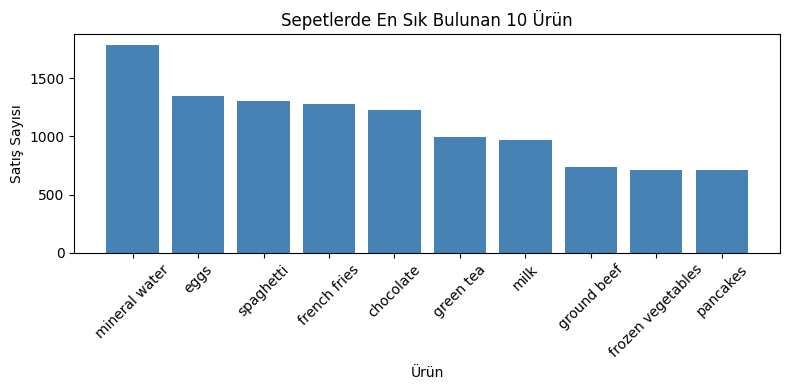

In [73]:
# 1. Sepetlerde En Sık Bulunan 10 Ürün
top_10 = basket_matrix.sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 4))
plt.bar(top_10.index, top_10.values, color='steelblue')
plt.title('Sepetlerde En Sık Bulunan 10 Ürün')
plt.xlabel('Ürün')
plt.ylabel('Satış Sayısı')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


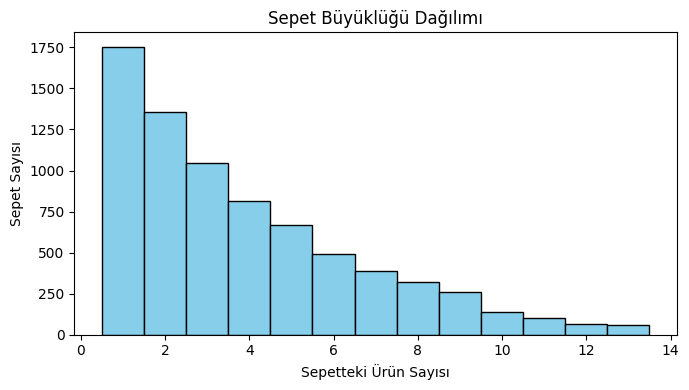

In [74]:
# 2. Sepet Büyüklüğü Dağılımı
basket_sizes = basket_matrix.sum(axis=1)

plt.figure(figsize=(7, 4))
plt.hist(basket_sizes, bins=range(1, 15), color='skyblue', edgecolor='black', align='left')
plt.title('Sepet Büyüklüğü Dağılımı')
plt.xlabel('Sepetteki Ürün Sayısı')
plt.ylabel('Sepet Sayısı')
plt.tight_layout()
plt.show()

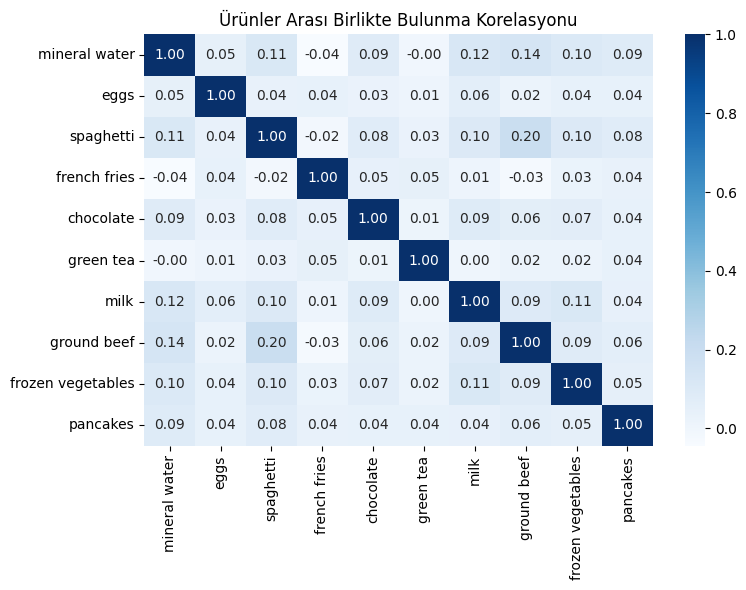

In [75]:
# 3. Ürünler Arası Korelasyon Isı Haritası
corr = basket_matrix[top_10.index].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Blues')
plt.title('Ürünler Arası Birlikte Bulunma Korelasyonu')
plt.tight_layout()
plt.show()

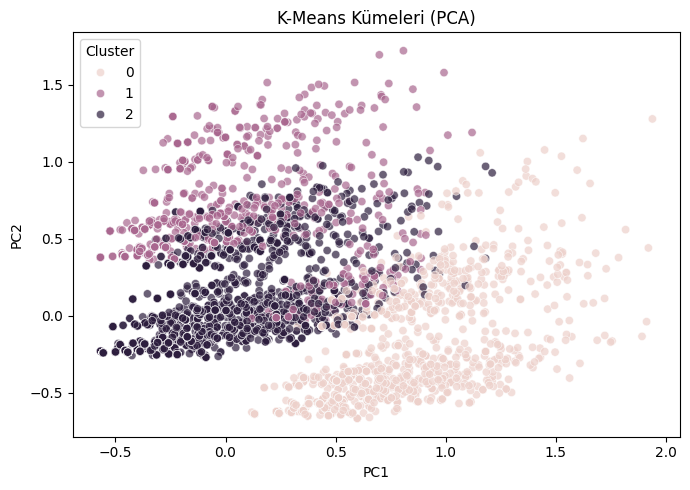

In [76]:
# Model Eğitimi (k=3)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
basket_matrix['Cluster'] = kmeans.fit_predict(X)

# PCA ile 2 Boyuta İndirgeme
pca = PCA(n_components=2, random_state=42)
pca_coords = pca.fit_transform(X)
pca_df = pd.DataFrame(pca_coords, columns=['PC1', 'PC2'])
pca_df['Cluster'] = basket_matrix['Cluster']

# PCA Saçılım Grafiği
plt.figure(figsize=(7, 5))
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=pca_df, alpha=0.7)
plt.title('K-Means Kümeleri (PCA)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.tight_layout()
plt.show()

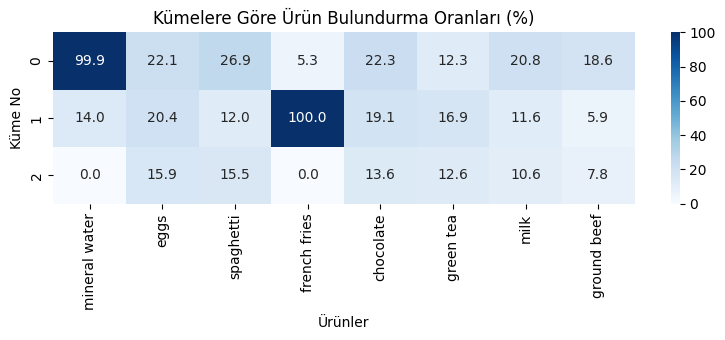

In [77]:
# Kümelerin popüler ürünleri bulundurma oranları (%)
cluster_profile = (basket_matrix.groupby('Cluster')[top_20_items[:8]].mean() * 100).round(1)

plt.figure(figsize=(8, 3.5))
sns.heatmap(cluster_profile, annot=True, fmt='.1f', cmap='Blues')
plt.title('Kümelere Göre Ürün Bulundurma Oranları (%)')
plt.xlabel('Ürünler')
plt.ylabel('Küme No')
plt.tight_layout()
plt.show()

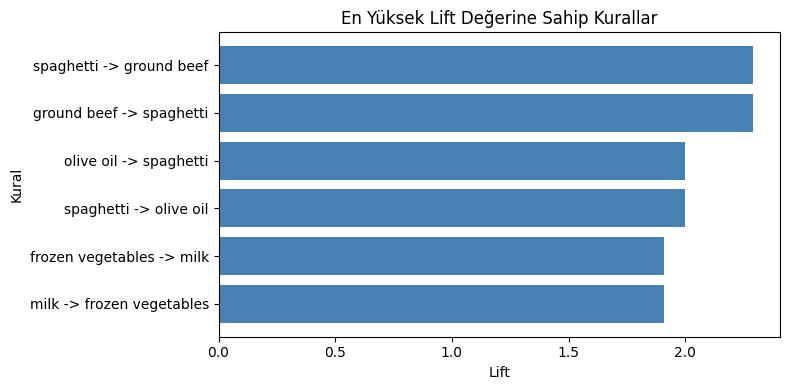

In [78]:
# Birliktelik Analizi
frequent_itemsets = apriori(X.astype(bool), min_support=0.02, use_colnames=True)
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.2)

top_rules = rules.sort_values(by='lift', ascending=False)[
    ['antecedents', 'consequents', 'support', 'confidence', 'lift']
].head(6)

top_rules['antecedents'] = top_rules['antecedents'].apply(lambda x: ', '.join(list(x)))
top_rules['consequents'] = top_rules['consequents'].apply(lambda x: ', '.join(list(x)))

# Lift Çubuk Grafiği
plot_rules = top_rules.copy()
plot_rules['Kural'] = plot_rules['antecedents'] + ' -> ' + plot_rules['consequents']
plot_rules = plot_rules.sort_values(by='lift', ascending=True)

plt.figure(figsize=(8, 4))
plt.barh(plot_rules['Kural'], plot_rules['lift'], color='steelblue')
plt.title('En Yüksek Lift Değerine Sahip Kurallar')
plt.xlabel('Lift')
plt.ylabel('Kural')
plt.tight_layout()
plt.show()